<a href="https://colab.research.google.com/github/epuskas/Foundations-in-AI-Clickbait-Project/blob/main/Team7_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing and Splitting the Clickbait Dataset

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("amananandrai/clickbait-dataset")

print("Path to dataset files:", path)

100%|██████████| 743k/743k [00:00<00:00, 50.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/amananandrai/clickbait-dataset/versions/1


In [2]:
import os
import pandas as pd

files = os.listdir(path)
print(f"Files in dataset: {files}")

csv_files = [f for f in files if f.endswith('.csv')]
if csv_files:
    df = pd.read_csv(os.path.join(path, csv_files[0]))
    display(df.head())
    display(df.info())
else:
    print("No CSV file found in the directory.")

Files in dataset: ['clickbait_data.csv']


,headline,clickbait
0,Should I Get Bings,1
1,Which TV Female Friend Group Do You Belong In,1
2,"The New ""Star Wars: The Force Awakens"" Trailer...",1
3,"This Vine Of New York On ""Celebrity Big Brothe...",1
4,A Couple Did A Stunning Photo Shoot With Their...,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32000 entries, 0 to 31999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   headline   32000 non-null  object
 1   clickbait  32000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 500.1+ KB


None

Class distribution:
clickbait
0    16001
1    15999
Name: count, dtype: int64


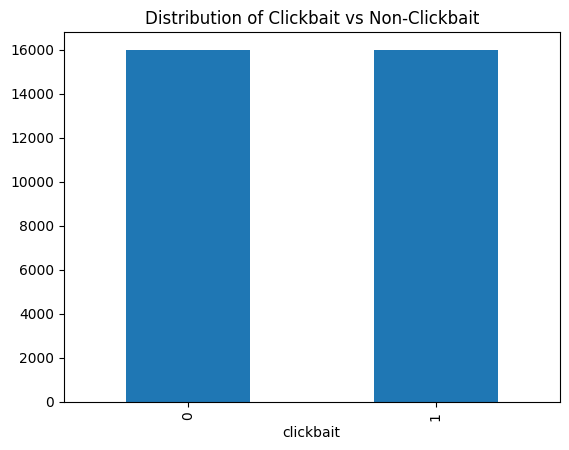

Training set shape: (25600, 5000)
Testing set shape: (6400, 5000)


In [3]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

#Setting seed for reproducibility
seed = 22
np.random.seed(seed)

#Checking the class balance of the dataset
print("Class distribution:")
print(df['clickbait'].value_counts())
df['clickbait'].value_counts().plot(kind='bar', title='Distribution of Clickbait vs Non-Clickbait')
plt.show()

#Splitting the dataset
X = df['headline']
y = df['clickbait']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)

#Text Vectorization using TF-IDF
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X_train = tfidf.fit_transform(X_train_raw)
X_test = tfidf.transform(X_test_raw)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# Model and Technical Choice: Logistic Regression, SVM, and Random Forest

Model Accuracy: 0.9515625

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      3200
           1       0.96      0.94      0.95      3200

    accuracy                           0.95      6400
   macro avg       0.95      0.95      0.95      6400
weighted avg       0.95      0.95      0.95      6400



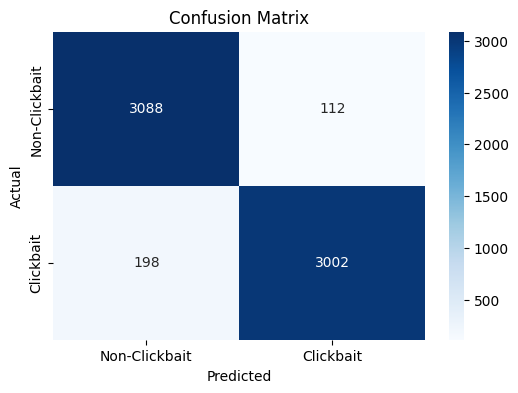

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

#Training Logistic Regression as our simple model baseline
model = LogisticRegression()
model.fit(X_train, y_train)

#Evaluating the model
y_pred = model.predict(X_test)

print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

#Visualize Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Clickbait', 'Clickbait'], yticklabels=['Non-Clickbait', 'Clickbait'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Training SVM (Linear Kernel)...

--- SVM Performance ---
Accuracy: 0.9542
F1-Score: 0.9540
ROC-AUC: 0.9894

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      3200
           1       0.96      0.95      0.95      3200

    accuracy                           0.95      6400
   macro avg       0.95      0.95      0.95      6400
weighted avg       0.95      0.95      0.95      6400



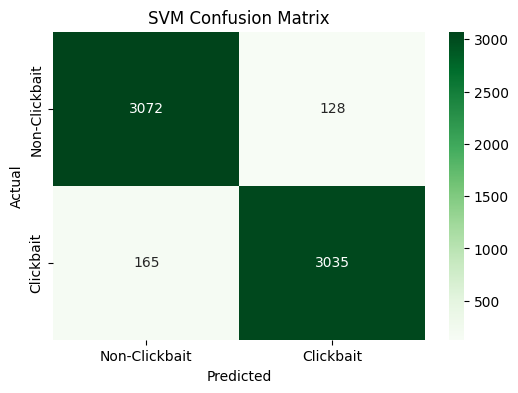

In [5]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

#SVM Implementation with Linear Kernel
svm_model = SVC(kernel='linear', probability=True, random_state=seed)
svm_model.fit(X_train, y_train)

#Predictions
y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

#Evaluation
print("\nSVM Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_svm):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_svm):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

#Confusion Matrix
plt.figure(figsize=(6, 4))
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Non-Clickbait', 'Clickbait'],
            yticklabels=['Non-Clickbait', 'Clickbait'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix')
plt.show()

Training Random Forest...

--- Random Forest Performance ---
Accuracy: 0.9170
F1-Score: 0.9200
ROC-AUC: 0.9753

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.88      0.91      3200
           1       0.89      0.95      0.92      3200

    accuracy                           0.92      6400
   macro avg       0.92      0.92      0.92      6400
weighted avg       0.92      0.92      0.92      6400



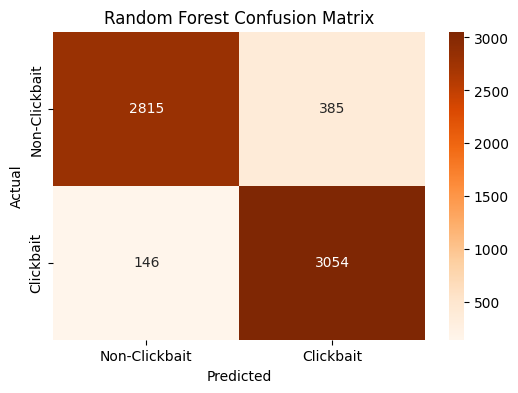

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

#Random Forest Implementation
rf_model = RandomForestClassifier(n_estimators=100, random_state=seed, n_jobs=-1)
rf_model.fit(X_train, y_train)

#Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

#Evaluation Metrics
print("\nRandom Forest Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

#Confusion Matrix
plt.figure(figsize=(6, 4))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Non-Clickbait', 'Clickbait'],
            yticklabels=['Non-Clickbait', 'Clickbait'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

# Comparison between the Models

,Model,Accuracy,F1-Score,ROC-AUC
0,Logistic Regression,0.9516,0.950,0.9893
1,SVM (Linear),0.9542,0.954,0.9894
2,Random Forest,0.9170,0.920,0.9753


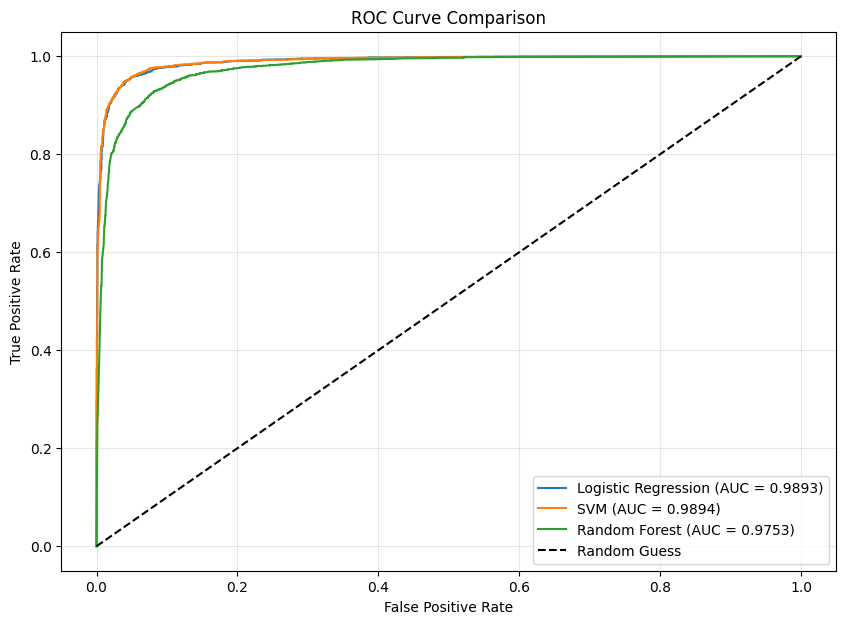

In [7]:
import pandas as pd
from sklearn.metrics import roc_curve, auc

#Comparison Table between all the models
results = {
    'Model': ['Logistic Regression', 'SVM (Linear)', 'Random Forest'],
    'Accuracy': [0.9516, 0.9542, 0.9170],
    'F1-Score': [0.95, 0.9540, 0.9200],
    'ROC-AUC': [0.9893, 0.9894, 0.9753]
}

results_df = pd.DataFrame(results)
display(results_df)

#Plot combined ROC Curves
plt.figure(figsize=(10, 7))

#Logistic Regression
y_prob_lr = model.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {results["ROC-AUC"][0]:.4f})')

#SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {results["ROC-AUC"][1]:.4f})')

#Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {results["ROC-AUC"][2]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Final Predictive Model (SVM)

In [8]:
def predict_clickbait(headlines):
    #vectorize the input headlines using the pre-trained tfidf
    vectorized_input = tfidf.transform(headlines)

    #Predictions and probabilities
    predictions = svm_model.predict(vectorized_input)
    probabilities = svm_model.predict_proba(vectorized_input)[:, 1]

    results = []
    for headline, pred, prob in zip(headlines, predictions, probabilities):
        label = "Clickbait" if pred == 1 else "Non-Clickbait"
        confidence = prob if pred == 1 else (1 - prob)
        results.append({
            'Headline': headline,
            'Prediction': label,
            'Confidence': f"{confidence:.2%}"
        })

    return pd.DataFrame(results)

#Testing the model with custom headlines:
custom_headlines = [
    "You Won't Believe What Happened To This Actor!",
    "10 Reasons Why Coffee Is Good For You",
    "Senate passes new bill on environmental protection",
    "Scientists discover new species in the Amazon rainforest",
    "She opened her door and her life changed forever..."
]

prediction_results = predict_clickbait(custom_headlines)
display(prediction_results)

,Headline,Prediction,Confidence
0,You Won't Believe What Happened To This Actor!,Clickbait,100.00%
1,10 Reasons Why Coffee Is Good For You,Clickbait,100.00%
2,Senate passes new bill on environmental protec...,Non-Clickbait,99.97%
3,Scientists discover new species in the Amazon ...,Non-Clickbait,99.13%
4,She opened her door and her life changed forev...,Clickbait,89.23%


# LLM Headline Rewriter


In [9]:
!pip install anthropic -q

import os
from google.colab import userdata
from anthropic import Anthropic

os.environ["ANTHROPIC_API_KEY"] = userdata.get("ANTHROPIC_API_KEY")
client = Anthropic()

print("API key loaded.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 956.9/956.9 kB 6.4 MB/s eta 0:00:00
API key loaded.


In [15]:
def rewrite_headline(headline):
    prompt = f"""You are a skilled news editor. The headline below has been flagged as clickbait.
Rewrite it as a neutral, factual, and honest news headline that still makes people want to click.

Rules:
- Keep the same topic and any facts from the original.
- Do NOT invent names, numbers, or details that are not in the original headline.
- Remove curiosity-gap tricks (e.g. "you won't believe", "what happened next"), all-caps, and exaggeration.
- Keep it engaging: use strong, active verbs and concrete language instead of vague or generic phrasing.
- Write like a headline a quality publication would run (think NYT or The Atlantic), not a press release.
- Return ONLY the rewritten headline, nothing else.

Headline: {headline}"""

    response = client.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=200,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.content[0].text.strip()

# Quick test
print(rewrite_headline("12 Secrets Airlines Don't Want You to Know!"))

What Airlines Don't Disclose to Passengers


In [16]:
def clickbait_pipeline(headlines):
    results = []

    for headline in headlines:
        #Classify the original headline with our SVM
        vec = tfidf.transform([headline])
        pred = svm_model.predict(vec)[0]
        prob = svm_model.predict_proba(vec)[0, 1]

        if pred == 0:
            #Not clickbait, no rewrite needed
            results.append({
                'Original Headline': headline,
                'Prediction': 'Non-Clickbait',
                'Confidence': f"{(1 - prob):.2%}",
                'Rewritten Headline': '—',
                'Rewrite Verified?': '—'
            })
        else:
            #Clickbait, so ask the LLM to rewrite it
            rewritten = rewrite_headline(headline)

            #verify the rewrite with our own SVM
            vec_new = tfidf.transform([rewritten])
            pred_new = svm_model.predict(vec_new)[0]
            prob_new = svm_model.predict_proba(vec_new)[0, 1]

            if pred_new == 0:
                verified = f"Yes — SVM now says Non-Clickbait ({(1 - prob_new):.2%} confidence)"
            else:
                verified = f"No — SVM still flags it as Clickbait ({prob_new:.2%})"

            results.append({
                'Original Headline': headline,
                'Prediction': 'Clickbait',
                'Confidence': f"{prob:.2%}",
                'Rewritten Headline': rewritten,
                'Rewrite Verified?': verified
            })

    return pd.DataFrame(results)

#Run the full pipeline on our test headlines:
custom_headlines = [
    "You Won't Believe What Happened To This Actor!",
    "10 Reasons Why Coffee Is Good For You",
    "Senate passes new bill on environmental protection",
    "Scientists discover new species in the Amazon rainforest",
    "She opened her door and her life changed forever..."
]

pipeline_results = clickbait_pipeline(custom_headlines)
pd.set_option('display.max_colwidth', None)
display(pipeline_results)

,Original Headline,Prediction,Confidence,Rewritten Headline,Rewrite Verified?
0,You Won't Believe What Happened To This Actor!,Clickbait,100.00%,Actor's Career Takes Unexpected Turn,Yes — SVM now says Non-Clickbait (97.12% confidence)
1,10 Reasons Why Coffee Is Good For You,Clickbait,100.00%,"The Health Benefits of Coffee, Explained",Yes — SVM now says Non-Clickbait (97.73% confidence)
2,Senate passes new bill on environmental protection,Non-Clickbait,99.97%,—,—
3,Scientists discover new species in the Amazon rainforest,Non-Clickbait,99.13%,—,—
4,She opened her door and her life changed forever...,Clickbait,89.23%,Woman's unexpected visitor transforms her life,No — SVM still flags it as Clickbait (67.53%)
